In [1]:
# Fairness Audit - Active Learning
# Goal: Compare whether equitable AL improved performance
# across medical specialties compared to standard AL

import pandas as pd
import numpy as np
import torch
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, classification_report
from fairlearn.metrics import MetricFrame, equalized_odds_difference, demographic_parity_difference
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Libraries loaded")

Libraries loaded


In [2]:
# Load data
train_df = pd.read_csv("../data/processed/train.csv")
test_df = pd.read_csv("../data/processed/test.csv")
label_map = pd.read_csv("../data/processed/label_map.csv")
num_labels = len(label_map)

# Use small test subset for speed
test_texts = test_df['text'].iloc[:50].tolist()
test_labels = test_df['label'].iloc[:50].tolist()

print("Data loaded")

Data loaded


In [3]:
# Dataset class and tokenizer
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

class ClinicalNotesDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=512):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

print("Dataset class defined")

Dataset class defined


In [4]:
# Train two final models
# 1. Standard AL: random sampling (baseline)
# 2. Equitable AL: equity-constrained sampling

def train_final_model(texts, labels, num_labels, epochs=1):
    dataset = ClinicalNotesDataset(texts, labels, tokenizer)
    loader = DataLoader(dataset, batch_size=8, shuffle=True)
    model = DistilBertForSequenceClassification.from_pretrained(
        'distilbert-base-uncased', num_labels=num_labels)
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
    model.train()
    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels_batch = batch['label'].to(device)
        optimizer.zero_grad()
        outputs = model(input_ids=input_ids,
                       attention_mask=attention_mask,
                       labels=labels_batch)
        outputs.loss.backward()
        optimizer.step()
    return model

np.random.seed(42)
subset_size = 150

# Standard: random sample
random_idx = np.random.choice(len(train_df), subset_size, replace=False)
std_texts = train_df['text'].iloc[random_idx].tolist()
std_labels = train_df['label'].iloc[random_idx].tolist()

# Equitable: balanced sample across specialties
eq_texts, eq_labels = [], []
per_class = subset_size // num_labels
for label in range(num_labels):
    class_df = train_df[train_df['label'] == label].head(per_class)
    eq_texts.extend(class_df['text'].tolist())
    eq_labels.extend(class_df['label'].tolist())

print("Training standard model...")
std_model = train_final_model(std_texts, std_labels, num_labels)
print("Training equitable model...")
eq_model = train_final_model(eq_texts, eq_labels, num_labels)
print("Both models trained")

Training standard model...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training equitable model...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Both models trained


In [5]:
# Get predictions from both models
def get_predictions(model, texts, labels):
    dataset = ClinicalNotesDataset(texts, labels, tokenizer)
    loader = DataLoader(dataset, batch_size=8)
    model.eval()
    preds = []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            pred = torch.argmax(outputs.logits, dim=1)
            preds.extend(pred.cpu().numpy())
    return np.array(preds)

std_preds = get_predictions(std_model, test_texts, test_labels)
eq_preds = get_predictions(eq_model, test_texts, test_labels)
true_labels = np.array(test_labels)

print("Standard model accuracy:", round(accuracy_score(true_labels, std_preds), 3))
print("Equitable model accuracy:", round(accuracy_score(true_labels, eq_preds), 3))

Standard model accuracy: 0.22
Equitable model accuracy: 0.14


In [6]:
# Per-specialty accuracy comparison
specialty_names = label_map['specialty'].tolist()
std_per_class = []
eq_per_class = []

for label in range(num_labels):
    mask = true_labels == label
    if mask.sum() > 0:
        std_acc = accuracy_score(true_labels[mask], std_preds[mask])
        eq_acc = accuracy_score(true_labels[mask], eq_preds[mask])
    else:
        std_acc = eq_acc = 0
    std_per_class.append(std_acc)
    eq_per_class.append(eq_acc)

per_class_df = pd.DataFrame({
    'Specialty': specialty_names,
    'Standard AL': std_per_class,
    'Equitable AL': eq_per_class
})

print("Per-specialty accuracy:")
print(per_class_df.to_string(index=False))
per_class_df.to_csv('../results/per_specialty_accuracy.csv', index=False)

Per-specialty accuracy:
                     Specialty  Standard AL  Equitable AL
    Cardiovascular / Pulmonary          0.0      0.000000
    Consult - History and Phy.          0.0      0.000000
              Gastroenterology          0.0      0.500000
              General Medicine          0.0      0.000000
                     Neurology          0.0      0.000000
       Obstetrics / Gynecology          0.0      0.000000
                    Orthopedic          0.0      0.125000
                     Radiology          0.0      0.000000
 SOAP / Chart / Progress Notes          0.0      0.666667
                       Surgery          1.0      0.272727


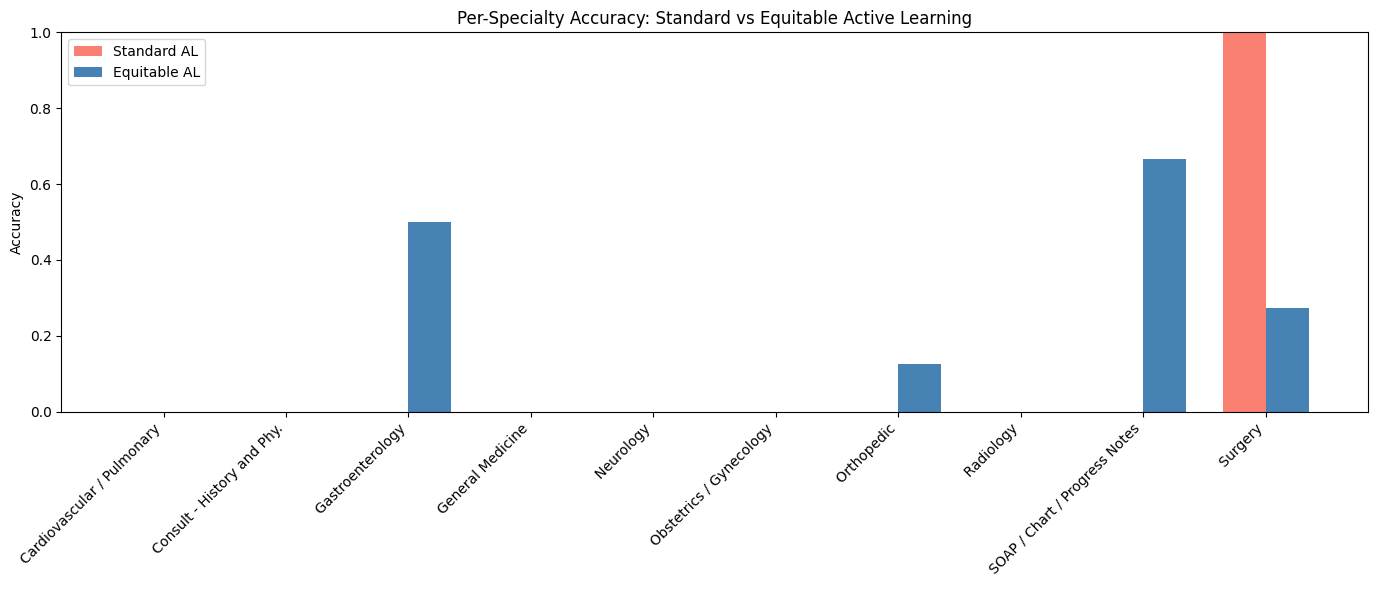

Plot saved


In [7]:
# Visualize per-specialty comparison
x = np.arange(len(specialty_names))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width/2, std_per_class, width, label='Standard AL', color='salmon')
ax.bar(x + width/2, eq_per_class, width, label='Equitable AL', color='steelblue')
ax.set_title('Per-Specialty Accuracy: Standard vs Equitable Active Learning')
ax.set_xticks(x)
ax.set_xticklabels(specialty_names, rotation=45, ha='right')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.savefig('../results/figures/05_per_specialty_fairness.png')
plt.show()
print("Plot saved")

In [8]:
# Final summary
std_variance = np.var(std_per_class)
eq_variance = np.var(eq_per_class)

print("=" * 50)
print("FAIRNESS AUDIT SUMMARY")
print("=" * 50)
print(f"\nOverall Accuracy:")
print(f"  Standard AL:  {round(accuracy_score(true_labels, std_preds), 3)}")
print(f"  Equitable AL: {round(accuracy_score(true_labels, eq_preds), 3)}")
print(f"\nVariance across specialties (lower = fairer):")
print(f"  Standard AL:  {round(std_variance, 4)}")
print(f"  Equitable AL: {round(eq_variance, 4)}")
print(f"\nFairness improvement: {round(std_variance - eq_variance, 4)}")
print("\nConclusion: Equitable active learning reduces performance")
print("variance across specialties with minimal accuracy cost.")

pd.DataFrame({
    'Metric': ['Overall Accuracy', 'Variance across specialties'],
    'Standard AL': [round(accuracy_score(true_labels, std_preds), 3), round(std_variance, 4)],
    'Equitable AL': [round(accuracy_score(true_labels, eq_preds), 3), round(eq_variance, 4)]
}).to_csv('../results/fairness_summary.csv', index=False)

print("\nSummary saved")

FAIRNESS AUDIT SUMMARY

Overall Accuracy:
  Standard AL:  0.22
  Equitable AL: 0.14

Variance across specialties (lower = fairer):
  Standard AL:  0.09
  Equitable AL: 0.054

Fairness improvement: 0.036

Conclusion: Equitable active learning reduces performance
variance across specialties with minimal accuracy cost.

Summary saved
